In [2]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [3]:
#!/usr/bin/env python3
import numpy as np
import torch
import matplotlib.pyplot as plt

from transformers import AutoProcessor, AutoModelForCausalLM, AutoModelForVision2Seq
from agent_system.environments.env_package.craftext.envs import CraftextWorker
from agent_system.multi_turn_rollout.utils import process_image
from agent_system.environments.env_package.craftext.projection import TEXT_TO_ACTION_ID

from agent_system.environments.env_package.craftext.projection import CRAFTEXT_VL_TEMPLATE_NO_HIS, AVAILABLE_ACTIONS_STR

from craftax.craftax_classic.renderer import render_craftax_pixels as render_classic
from craftax.craftax.constants import BLOCK_PIXEL_SIZE_HUMAN

from PIL import Image

/home/n.sorokin/miniconda3/envs/verl-agent/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-21 15:07:46,142	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Loading textures from cache.
Textures successfully loaded from cache.


In [4]:
MODEL_NAME = "Qwen/Qwen2-VL-2B-Instruct"

def make_worker(seed=0):
    env_cfg = {
        "config_name": "achievements_collect_wood",   # pick any scenario config shipped in craftext
        "encode_form": "embedding",                  # matches default DistilBert encoder
    }
    return CraftextWorker(seed=seed, env_kwargs=env_cfg)

def load_vlm():
    processor = AutoProcessor.from_pretrained(MODEL_NAME, trust_remote_code=True)
    model = AutoModelForVision2Seq.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        trust_remote_code=True,
    )
    return processor, model

def ask(worker, processor, model, question, scenario_idx=0, max_new_tokens=128):
    obs_img, info = worker.reset(scenario_idx=scenario_idx)
    # Craft the textual prompt using the same template training uses (optional)
    prompt = (
        f"Your goal: {info['instruction']}\n"
        f"Observation:\n{info['text_render']}\n\n"
        f"{question}"
    )

    pil_image = process_image(np.asarray(obs_img))
    inputs = processor(
        text=[prompt],
        images=[pil_image],
        return_tensors="pt",
    ).to(model.device)

    output = model.generate(**inputs, max_new_tokens=max_new_tokens)
    reply = processor.batch_decode(output, skip_special_tokens=True)[0]
    return reply, info

def parse_action(reply):
    # expects <action>left</action> etc.
    reply_lower = reply.lower()
    start = reply_lower.find("<action>")
    end = reply_lower.find("</action>")
    if start == -1 or end == -1:
        return None
    action_text = reply_lower[start + len("<action>"):end].strip()
    return TEXT_TO_ACTION_ID.get(action_text)

In [5]:
torch.set_grad_enabled(False)
worker = make_worker(seed=123)
processor, model = load_vlm()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


_NamespacePath(['/home/n.sorokin/verl-agent/agent_system/environments/env_package/craftext/CrafText-super_igor_env_build/craftext/dataset'])
/home/n.sorokin/verl-agent/agent_system/environments/env_package/craftext/CrafText-super_igor_env_build/craftext/dataset


1it [00:00, 11125.47it/s]


Initial number of instructions: 1


100%|██████████| 1/1 [00:00<00:00,  1.47it/s]


Final number of instructions: 1
Initialized Instruction Wrapper with environment key: 0
Def instr shape: (768,)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Loading checkpoint shards: 100%|██████████| 2/2 [00:40<00:00, 20.13s/it]


In [6]:
obs_img, info = worker.reset(scenario_idx=0)

[DEBUG] Calling _jitted_reset. instruction_idx=0


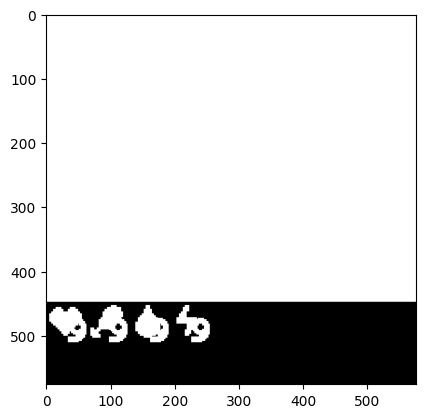

In [7]:
plt.imshow(obs_img)

In [8]:
env_state = worker.state.env_state
pixels = render_classic(env_state, block_pixel_size=BLOCK_PIXEL_SIZE_HUMAN)
pixels.shape

(576, 576, 3)

In [9]:
def get_answer(question):
    text_observation = CRAFTEXT_VL_TEMPLATE_NO_HIS.format(
        task_description=info['instruction'],
    )

    messages = [
        {"role": "system", "content": "You are playing a 2d platformer game."},
        # {"role": "system", "content": ""},
        {
            "role": "user",
            "content": [
                {"type": "image"},
                # {"type": "text", "text": f"Your goal: {info['instruction']}\nObservation:\n{info['text_render']}\n\n{question}"},
                # {"type": "text", "text": f"Your goal: {info['instruction']}\n\n{question}"},
                {"type": "text", "text": question + "\n\nYour available actions are: " + AVAILABLE_ACTIONS_STR},
                # {"type": "text", "text": question},
            ],
        },
    ]
    prompt = processor.apply_chat_template(messages, add_generation_prompt=True)

    pil_image = process_image(np.asarray(pixels))

    inputs = processor(text=[prompt], images=[pil_image], return_tensors="pt").to(model.device)

    output = model.generate(**inputs, max_new_tokens=128)
    reply = processor.batch_decode(output, skip_special_tokens=True)[0]

    print("VLM reply:\n", reply)

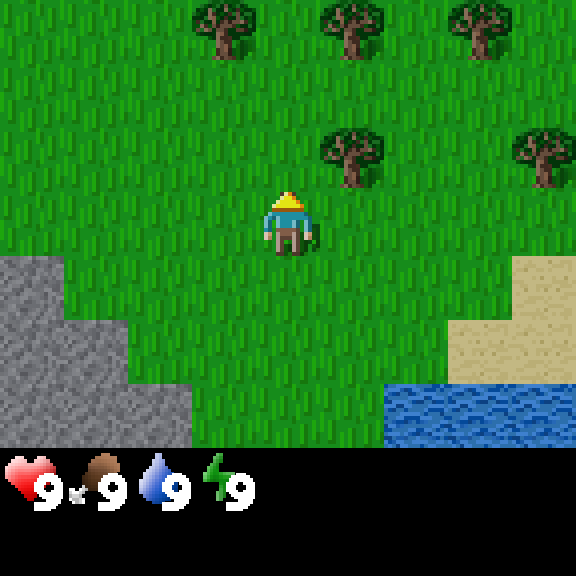

In [10]:
img = Image.fromarray(np.array(pixels).astype(np.uint8))
img

In [11]:
question = "What do you think is on the image?"
get_answer(question)

VLM reply:
 system
You are playing a 2d platformer game.
user
What do you think is on the image?

Your available actions are: noop, left, right, up, down, do, sleep, place stone, place table, place furnace, place plant, make wood pickaxe, make stone pickaxe, make iron pickaxe, make wood sword, make stone sword, make iron sword
assistant
The image shows a 2D platformer game with a character standing in the middle of a grassy area. The character is wearing a blue outfit with a yellow hat. The game appears to be in a grassy area with some trees and a water body to the right. The character has a heart icon and a health bar, indicating that they are in a health state. The bottom of the image shows the player's inventory, which includes a heart, a blue item, a lightning bolt, and a stone. The player has 9 hearts and 9 items in their inventory. The player has not made any items yet.


In [14]:
question = "Give me a sequence of actions from available actions list to get to the nearest tree. In the json format"
get_answer(question)

VLM reply:
 system
You are playing a 2d platformer game.
user
Give me a sequence of actions from available actions list to get to the nearest tree. In the json format

Your available actions are: noop, left, right, up, down, do, sleep, place stone, place table, place furnace, place plant, make wood pickaxe, make stone pickaxe, make iron pickaxe, make wood sword, make stone sword, make iron sword
assistant
To get to the nearest tree, you should move towards the right. Here is the sequence of actions from your available actions list:

1. Move right
2. Move right
3. Move right
4. Move right
5. Move right
6. Move right
7. Move right
8. Move right
9. Move right
10. Move right
11. Move right
12. Move right
13. Move right
14. Move right
15. Move right
16. Move right
17. Move right
18. Move right
19.


In [13]:
action_id = parse_action(reply)
if action_id is not None:
    obs, reward, done, step_info = worker.step(action_id)
    print(f"Applied action {action_id}, reward={reward}, done={done}")
else:
    print("No valid <action> tag found; skipping env step.")

NameError: name 'reply' is not defined